# Inspect the published StocBench datasets

A quick look at the downloaded 64 × 64 stochastic and deterministic data. Run this with the `fgd` Python environment. The trajectory files are opened with NumPy memory mapping; only individual frames are read. The large stochastic test ensemble (`raw`) is **never loaded**. No training, simulation, or full-dataset statistics are run.

The solver describes trajectories as `(samples, frames, channels, height, width)`. The stochastic data has one vorticity channel. The deterministic data has vorticity in channel 0 and the known forcing in channel 1. Vorticity is normalized as described in `solver/__init__.py`; the deterministic forcing channel is stored as is.

In [1]:
import os
import sys
import zipfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

data_root = Path(os.environ.get('STOCBENCH_DATA_DIR', '/scratch/jbosca/stocbench-data')).expanduser()
stoc_dir = data_root / 'incns_stoc' / '64'
det_dir = data_root / 'incns_det' / '64'
for folder in (stoc_dir, det_dir):
    if not folder.is_dir():
        raise FileNotFoundError(f'Dataset folder missing: {folder}. Set STOCBENCH_DATA_DIR to the download root.')
print('Python:', sys.executable)
print('Dataset root:', data_root)


Python: /home/jbosca/.conda-envs/fgd/bin/python
Dataset root: /scratch/jbosca/stocbench-data


In [2]:
for label, folder in [('stochastic', stoc_dir), ('deterministic', det_dir)]:
    trajectories = sorted(folder.glob('traj_seed_*.npy'))
    ensembles = sorted(folder.glob('step_seed_*.npz'))
    spectrum = folder / 'enstrophy_spec.npy'
    print(f'{label}: {len(trajectories)} trajectory files, {len(ensembles)} test ensemble files, spectrum: {spectrum.exists()}')
    print('  trajectory seeds:', [p.stem.removeprefix('traj_seed_') for p in trajectories])
    if ensembles:
        print('  test seed range:', ensembles[0].stem.removeprefix('step_seed_'), 'to', ensembles[-1].stem.removeprefix('step_seed_'))


stochastic: 3 trajectory files, 48 test ensemble files, spectrum: True
  trajectory seeds: ['42', '43', '44']
  test seed range: 100 to 147
deterministic: 4 trajectory files, 48 test ensemble files, spectrum: False
  trajectory seeds: ['42', '43', '44', '45']
  test seed range: 100 to 147


## Trajectory shape and a few frames

`np.load(..., mmap_mode='r')` reads the file header now and fetches frame values only when indexed. The examples below inspect sample 0, frames 0 and 1. These are illustrative local values, not statistics over the dataset.

In [3]:
stoc_path = stoc_dir / 'traj_seed_42.npy'
det_path = det_dir / 'traj_seed_42.npy'
stoc_traj = np.load(stoc_path, mmap_mode='r', allow_pickle=False)
det_traj = np.load(det_path, mmap_mode='r', allow_pickle=False)
for label, path, trajectory in [('stochastic', stoc_path, stoc_traj), ('deterministic', det_path, det_traj)]:
    print(f'{label}: {path.name}, shape={trajectory.shape}, dtype={trajectory.dtype}, file size={path.stat().st_size / 2**30:.2f} GiB')

stoc_vort_0 = np.asarray(stoc_traj[0, 0, 0])
stoc_vort_1 = np.asarray(stoc_traj[0, 1, 0])
det_vort_0 = np.asarray(det_traj[0, 0, 0])
det_vort_1 = np.asarray(det_traj[0, 1, 0])
det_forcing_0 = np.asarray(det_traj[0, 0, 1])
print('One stochastic vorticity frame:', stoc_vort_0.shape, 'min/max:', float(stoc_vort_0.min()), float(stoc_vort_0.max()))
print('One deterministic forcing frame:', det_forcing_0.shape, 'min/max:', float(det_forcing_0.min()), float(det_forcing_0.max()))
print('One-step training window shapes (initial, target):', stoc_traj[0, 0:1].shape, stoc_traj[0, 1:2].shape)


stochastic: traj_seed_42.npy, shape=(500, 200, 1, 64, 64), dtype=float32, file size=1.53 GiB
deterministic: traj_seed_42.npy, shape=(500, 200, 2, 64, 64), dtype=float32, file size=3.05 GiB
One stochastic vorticity frame: (64, 64) min/max: -4.9036054611206055 3.6548054218292236
One deterministic forcing frame: (64, 64) min/max: -4.605621814727783 4.634438514709473
One-step training window shapes (initial, target): (1, 1, 64, 64) (1, 1, 64, 64)


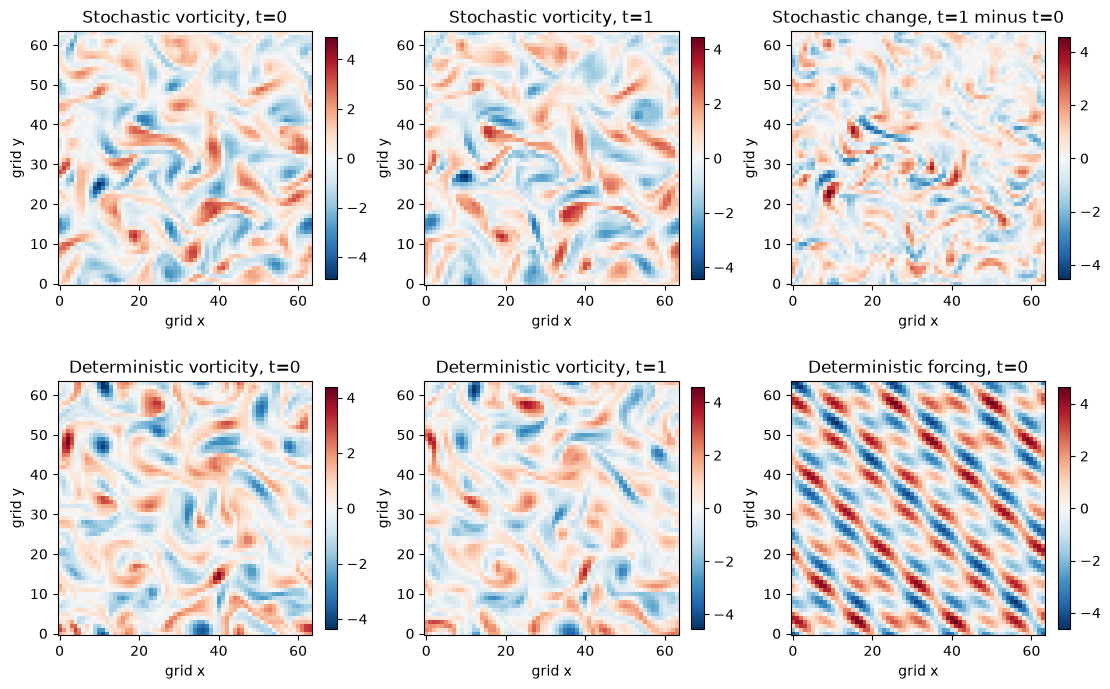

In [4]:
panels = [
    ('Stochastic vorticity, t=0', stoc_vort_0),
    ('Stochastic vorticity, t=1', stoc_vort_1),
    ('Stochastic change, t=1 minus t=0', stoc_vort_1 - stoc_vort_0),
    ('Deterministic vorticity, t=0', det_vort_0),
    ('Deterministic vorticity, t=1', det_vort_1),
    ('Deterministic forcing, t=0', det_forcing_0),
]
fig, axes = plt.subplots(2, 3, figsize=(11, 7), constrained_layout=True)
for ax, (title, field) in zip(axes.flat, panels):
    limit = float(np.max(np.abs(field))) or 1.0
    image = ax.imshow(field, cmap='RdBu_r', vmin=-limit, vmax=limit, origin='lower')
    ax.set_title(title)
    ax.set_xlabel('grid x')
    ax.set_ylabel('grid y')
    fig.colorbar(image, ax=ax, shrink=0.75)
plt.show()


## One-step reference files

The stochastic `step_seed_*.npz` files contain an initial vorticity field (`init`), ensemble `mean` and `std`, and many one-step draws (`raw`). The downloaded deterministic directory also contains `step_seed_*.npz` files, with a two-channel `init` and `mean`/`std`, but no `raw`; the benchmark's deterministic evaluation loader uses `traj_seed_45.npy` instead. The next cell checks NPZ shapes from ZIP/NumPy headers without expanding `raw` into memory, then plots only three small stochastic arrays.

stochastic: step_seed_100.npz
  init.npy: shape=(1, 64, 64), dtype=float32, uncompressed size=0.0 MiB
  mean.npy: shape=(1, 64, 64), dtype=float32, uncompressed size=0.0 MiB
  std.npy: shape=(1, 64, 64), dtype=float32, uncompressed size=0.0 MiB
  raw.npy: shape=(5000, 1, 1, 64, 64), dtype=float32, uncompressed size=78.1 MiB
deterministic: step_seed_100.npz
  init.npy: shape=(2, 64, 64), dtype=float32, uncompressed size=0.0 MiB
  mean.npy: shape=(1, 64, 64), dtype=float32, uncompressed size=0.0 MiB
  std.npy: shape=(1, 64, 64), dtype=float32, uncompressed size=0.0 MiB


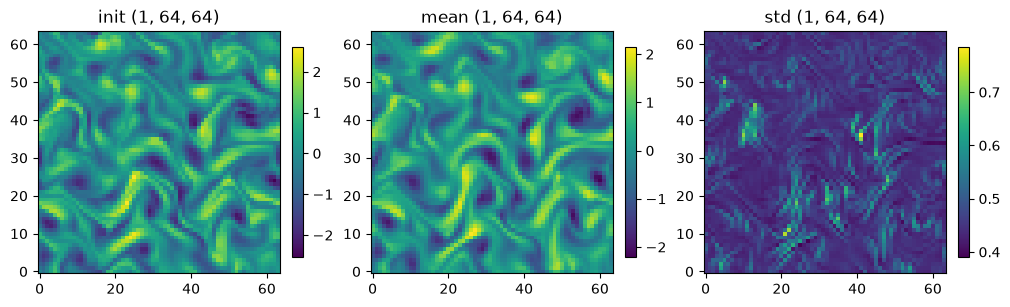

In [5]:
stats_path = stoc_dir / 'step_seed_100.npz'
for label, folder in [('stochastic', stoc_dir), ('deterministic', det_dir)]:
    path = folder / 'step_seed_100.npz'
    if not path.exists():
        continue
    print(f'{label}: {path.name}')
    with zipfile.ZipFile(path) as archive:
        for member in archive.infolist():
            with archive.open(member) as stream:
                version = np.lib.format.read_magic(stream)
                if version == (1, 0):
                    shape, fortran_order, dtype = np.lib.format.read_array_header_1_0(stream)
                elif version == (2, 0):
                    shape, fortran_order, dtype = np.lib.format.read_array_header_2_0(stream)
                else:
                    raise ValueError(f'Unsupported NumPy array format {version} in {member.filename}')
            print(f'  {member.filename}: shape={shape}, dtype={dtype}, uncompressed size={member.file_size / 2**20:.1f} MiB')

with np.load(stats_path, allow_pickle=False) as ensemble:
    small_fields = {name: ensemble[name] for name in ('init', 'mean', 'std')}

fig, axes = plt.subplots(1, 3, figsize=(10, 3), constrained_layout=True)
for ax, (name, field) in zip(axes, small_fields.items()):
    image = ax.imshow(field.squeeze(), cmap='viridis', origin='lower')
    ax.set_title(f'{name} {field.shape}')
    fig.colorbar(image, ax=ax, shrink=0.75)
plt.show()


## Optional reference spectrum

If present, `enstrophy_spec.npy` is a small one-dimensional reference spectrum used by the benchmark's rollout metric. Reading it is inexpensive.

In [6]:
for label, folder in [('stochastic', stoc_dir), ('deterministic', det_dir)]:
    spectrum_path = folder / 'enstrophy_spec.npy'
    if spectrum_path.exists():
        spectrum = np.load(spectrum_path, allow_pickle=False)
        print(f'{label} reference spectrum: shape={spectrum.shape}, dtype={spectrum.dtype}')
    else:
        print(f'{label}: no reference spectrum file')


stochastic reference spectrum: shape=(46,), dtype=float32
deterministic: no reference spectrum file
